# Esercizio 1

Carichiamo il dataset e facciamo un'analisi esplorativa

In [ ]:
import pandas as pd
df = pd.read_csv("dataset_esercitazione.csv")
print(df.shape)
print(df.head())


(9105, 43)
        age     sex            dzgroup  ... adls  adlsc  death
0  62.84998    male        Lung Cancer  ...  7.0    7.0      0
1  60.33899  female          Cirrhosis  ...  1.0    1.0      1
2  52.74698  female          Cirrhosis  ...  0.0    0.0      1
3  42.38498  female        Lung Cancer  ...  0.0    0.0      1
4  79.88495  female  ARF/MOSF w/Sepsis  ...  2.0    2.0      0

[5 rows x 43 columns]


Dobbiamo eliminare le variabili di **outcome**, in ambito medico e statistico, l'**outcome** (esito o risultato) è la conseguenza clinica finale osservata sul paziente (ad esempio: se il paziente è deceduto o meno, la durata della degenza, i costi totali dell'ospedalizzazione, o lo stato di salute a una certa scadenza).

Più in generale, scorrendo la tabella delle variabili nel PDF, rientrano tra gli outcome o le prognosi:
- le variabili sotto la categoria *costi*, $(charges, totcst, totmcst, avtisst)$.
- la variabile di esito principale/target come $death$ 

In [8]:
target = 'death'
cols_to_drop = ['charges', 'totcst', 'totmcst', 'avtisst', 'dzgroup', 'dzclass', target]

X = df.drop(columns=cols_to_drop)
y = df[target]

print(f"Dataset iniziale: {X.shape[1]}")
print(f"Target: {target}")
print(f"Eliminare: {cols_to_drop}")
print(X.head())


Dataset iniziale: 36
Target: death
Eliminare: ['charges', 'totcst', 'totmcst', 'avtisst', 'dzgroup', 'dzclass', 'death']
        age     sex  num.co   edu      income  ...  bun urine  adlp  adls  adlsc
0  62.84998    male       0  11.0    $11-$25k  ...  NaN   NaN   7.0   7.0    7.0
1  60.33899  female       2  12.0    $11-$25k  ...  NaN   NaN   NaN   1.0    1.0
2  52.74698  female       2  12.0  under $11k  ...  NaN   NaN   1.0   0.0    0.0
3  42.38498  female       2  11.0  under $11k  ...  NaN   NaN   0.0   0.0    0.0
4  79.88495  female       1   NaN         NaN  ...  NaN   NaN   NaN   2.0    2.0

[5 rows x 36 columns]


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.05, random_state=42, stratify=y)

# Individuiamo il numero di features mancanti
print(f"Dati mancanti --> Train: {X_train.isnull().sum().sum()}, Test --> {X_test.isnull().sum().sum()} ")

# Individuiamo le colonne numeriche e categoriche
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X_train.select_dtypes(include=['string', 'object', 'category']).columns

# Creiamo la Pipeline di preprocessing

# 1. imputer con mediana e scaling per le features numeriche
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. imputer con constant_value e OrdinalEncoder per le features categoriche
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# impostiamo l'output in modo da non dover ricreare manualmente i DataFrame
preprocessor.set_output(transform='pandas')

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Dati mancanti --> Train: {X_train_processed.isnull().sum().sum()}, Test --> {X_test_processed.isnull().sum().sum()} ")


Dati mancanti --> Train: 38985, Test --> 2108 
Dati mancanti --> Train: 0, Test --> 0 


# Gestione della multicolliearità tramite matrice di correlazione


Colonne da eliminare: []


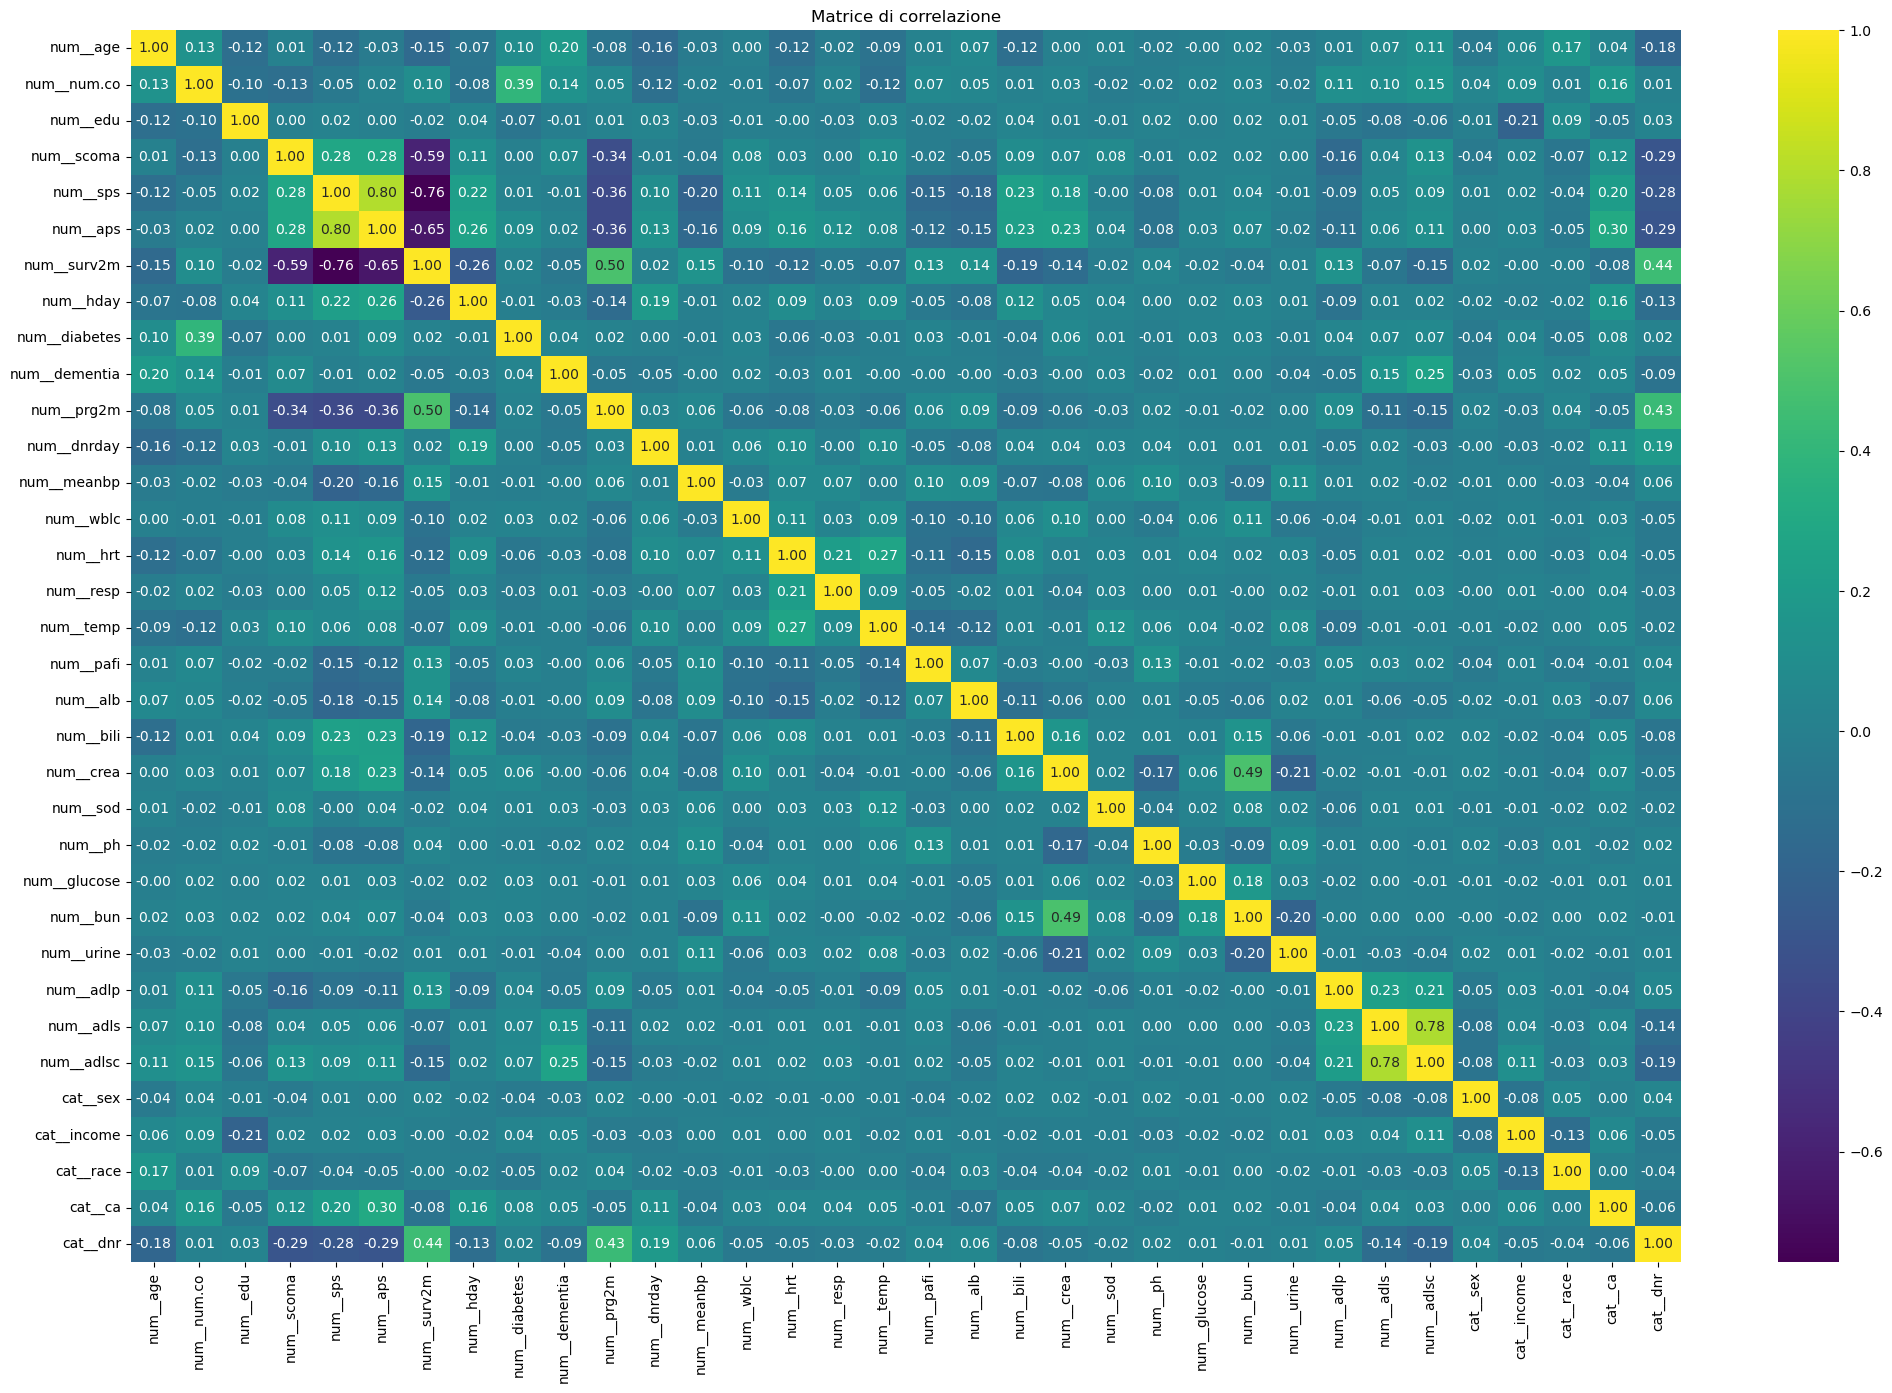

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

corr_matrix = X_train_processed.corr()
threshold = 0.80
plt.figure(figsize=(25,16))
sns.heatmap(corr_matrix, cmap="viridis", annot=True, fmt='.2f')
plt.title("Matrice di correlazione")

# devo prendere dalla matrice triangolare superiore solamente le classi che superano il threshold

tr_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

#colonne da droppare
drop = tr_upper.columns[(tr_upper.abs() > threshold).sum() > 0].tolist()
print(f"Colonne da eliminare: {drop}")

X_train_processed = X_train_processed.drop(columns=drop)
X_test_processed = X_test_processed.drop(columns=drop)

# Selezione features tramite RandomForestClassifier


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train_processed, y_train)
selector = SelectFromModel(estimator=rfc, threshold='mean')

sel = X_train_processed.columns[selector.get_support()]
print(f"Feature selezionate: {list(sel)}")

Feature selezionate: ['num__age', 'num__sps', 'num__aps', 'num__surv2m', 'num__prg2m', 'num__dnrday', 'num__meanbp', 'num__wblc', 'num__hrt', 'num__temp', 'num__pafi', 'num__crea', 'num__glucose', 'cat__ca', 'cat__dnr']


# Clustering tramite DBSCAN

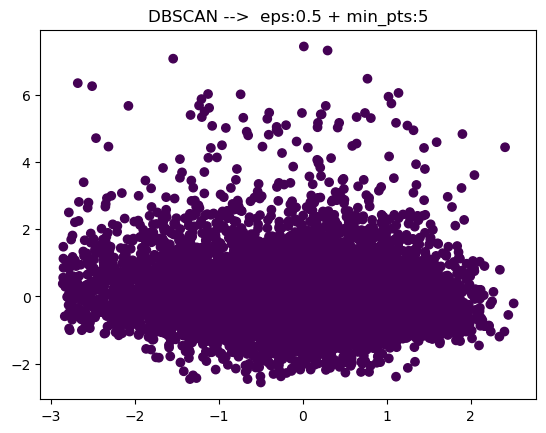

Numero di cluster: 0
Numero di rumori: 8649
Percentuale di rumore: 100.00%


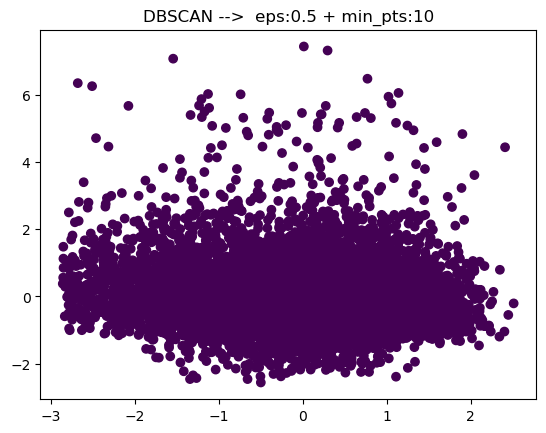

Numero di cluster: 0
Numero di rumori: 8649
Percentuale di rumore: 100.00%


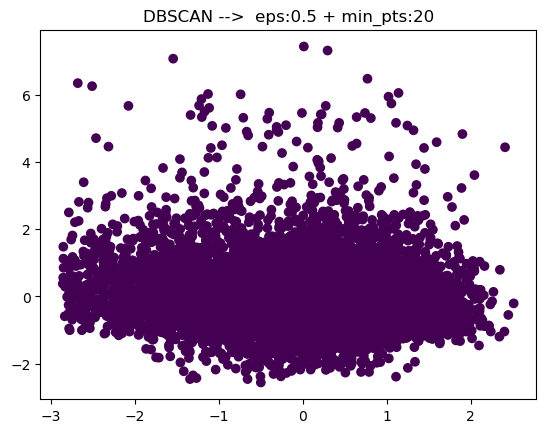

Numero di cluster: 0
Numero di rumori: 8649
Percentuale di rumore: 100.00%


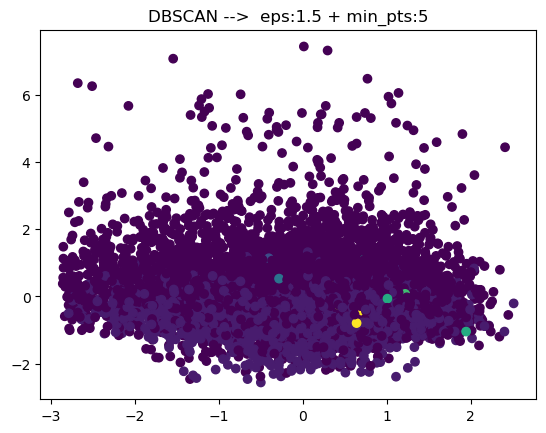

Numero di cluster: 13
Numero di rumori: 5312
Percentuale di rumore: 61.42%


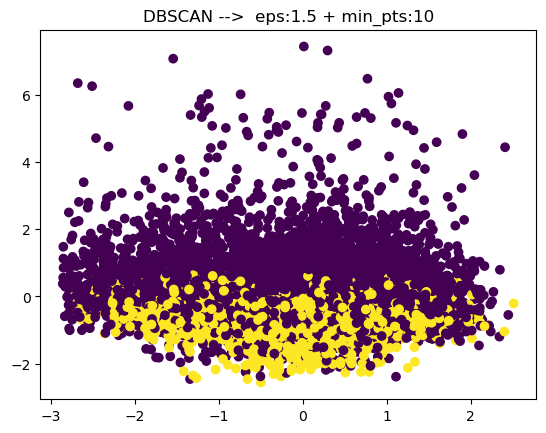

Numero di cluster: 1
Numero di rumori: 5759
Percentuale di rumore: 66.59%


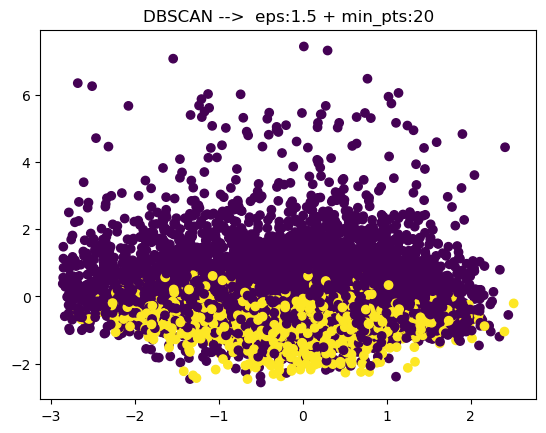

Numero di cluster: 1
Numero di rumori: 6210
Percentuale di rumore: 71.80%


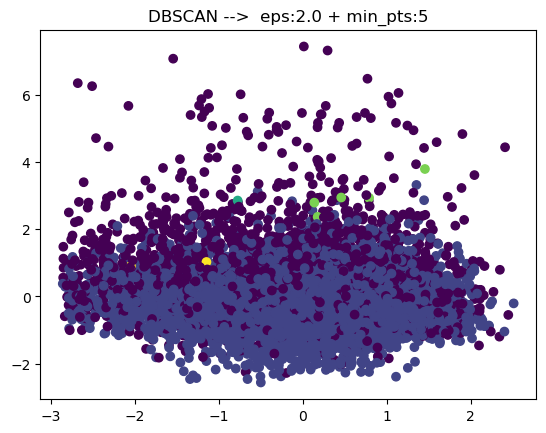

Numero di cluster: 5
Numero di rumori: 2453
Percentuale di rumore: 28.36%


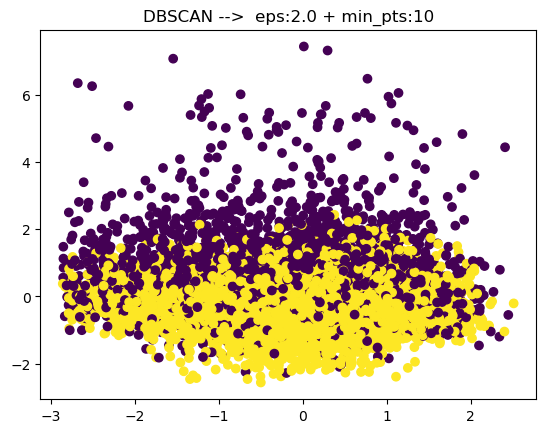

Numero di cluster: 1
Numero di rumori: 2831
Percentuale di rumore: 32.73%


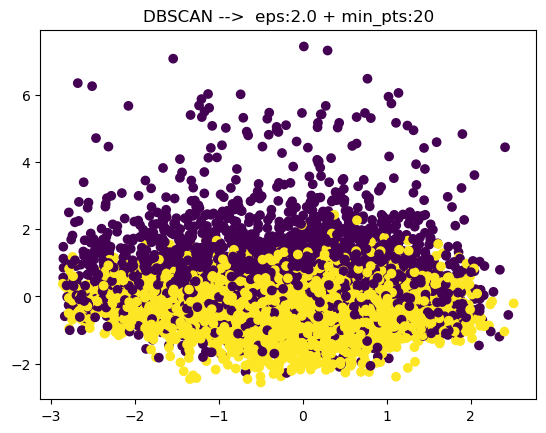

Numero di cluster: 1
Numero di rumori: 3335
Percentuale di rumore: 38.56%


In [25]:
from sklearn.cluster import DBSCAN

X_train_fin = X_train_processed[sel]
X_test_fin = X_test_processed[sel]

eps_list = [0.5, 1.5, 2.0]
min_pts_list = [5, 10, 20]

for eps in eps_list:
    for min_pts in min_pts_list:
        dbscan = DBSCAN(eps=eps, min_samples=min_pts)
        labels = dbscan.fit_predict(X_train_fin)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0) #numero di cluster

        n_noises = list(labels).count(-1) #numero di rumori

        noise = (n_noises/(len(labels))) * 100 #percentuale di rumore
        plt.scatter(X_train_fin.iloc[:, 0], X_train_fin.iloc[:, 1], cmap='viridis', c=labels)
        plt.title(f"DBSCAN -->  eps:{eps} + min_pts:{min_pts}")
        plt.show()
        print(f"Numero di cluster: {n_clusters}")
        print(f"Numero di rumori: {n_noises}")
        print(f"Percentuale di rumore: {noise:.2f}%")

# Calcolo delle metriche del clustering

Il modello migliore risulta essere quello con eps=2 e min_pts=5

Purity train: 65.69%, Accuracy train: 24.65%
Purity test: 68.20%, Accuracy test: 32.02%


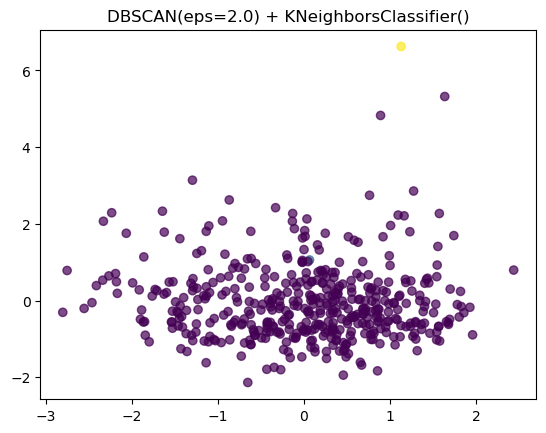

In [ ]:
from sklearn.metrics.cluster import contingency_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#funzione di purity
def purity(y_true, labels_cluster):
    mask = (labels_cluster != -1)
    y_clean = y_true[mask]
    labels_clean = labels_cluster[mask]

    if len(y_clean) == 0:
        return 0.0

    cont_matrix = contingency_matrix(y_clean, labels_clean)

    return cont_matrix.max(axis=0).sum() / cont_matrix.sum()


best_dbscan = DBSCAN(eps=2.0, min_samples=5)
labels_train = best_dbscan.fit_predict(X_train_fin)

# DBSCAN non assegna direttamente un cluster ai nuovi punti del test set.
# Usiamo KNN per stimare il cluster dei punti di test sulla base dei cluster
# trovati da DBSCAN nel training set.

#il numero di neighbors è motivato dal numero di cluters relativi al modello migliore
knn = KNeighborsClassifier(n_neighbors=5)

# Escludiamo dal training di KNN i punti classificati come rumore
mask_train = (labels_train != -1)

# addestriamo KNN solo con i punti non rumorosi e le relative etichette

knn.fit(X_train_fin.loc[mask_train], labels_train[mask_train])

# Assegniamo ai punti del test il cluster più probabile
labels_test = knn.predict(X_test_fin)

# Calcoliamo la purezza confrontando i cluster con la variabile reale death
purity_train = purity(y_train, labels_train)
purity_test = purity(y_test, labels_test)

print(f"Purity train: {purity_train * 100:.2f}%, Accuracy train: {accuracy_score(y_train, labels_train)  * 100:.2f}%")
print(f"Purity test: {purity_test * 100:.2f}%, Accuracy test: {accuracy_score(y_test, labels_test) * 100:.2f}%")

print

#Visualizziamo il test set usando le prime due feature selezionate
f1,f2 = sel[0], sel[1]
plt.scatter(X_test_fin[f1], X_test_fin[f2], cmap='viridis', c=labels_test, alpha=0.7)
plt.title(f"{best_dbscan} + {knn}")
plt.show()


# Utilizziamo un altro metodo di clustering

Purity train: 68.41%, Accuracy train: 13.34%
Purity test: 69.96%, Accuracy test: 11.62%


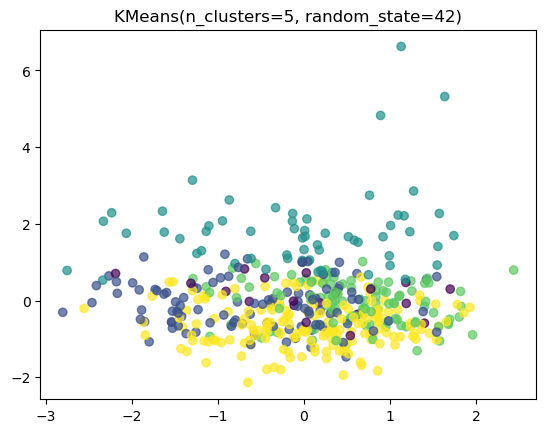

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, n_init='auto', random_state=42)
labels_train_kmeans = kmeans.fit_predict(X_train_fin)
labels_test_kmeans = kmeans.predict(X_test_fin)

purity_train_k = purity(y_train, labels_train_kmeans)
purity_test_k = purity(y_test, labels_test_kmeans)


print(f"Purity train: {purity_train_k * 100:.2f}%, Accuracy train: {accuracy_score(y_train, labels_train_kmeans) * 100:.2f}%")
print(f"Purity test: {purity_test_k * 100:.2f}%, Accuracy test: {accuracy_score(y_test, labels_test_kmeans) * 100:.2f}%")

f1, f2 = sel[0], sel[1]
plt.scatter(X_test_fin[f1], X_test_fin[f2], c=labels_test_kmeans, cmap='viridis', alpha=0.7)
plt.title(f"{kmeans}")
plt.show()



# Clustering con GaussianMixture

Purity train: 68.10%, Accuracy train: 14.96%
Purity test: 68.20%, Accuracy test: 14.91%


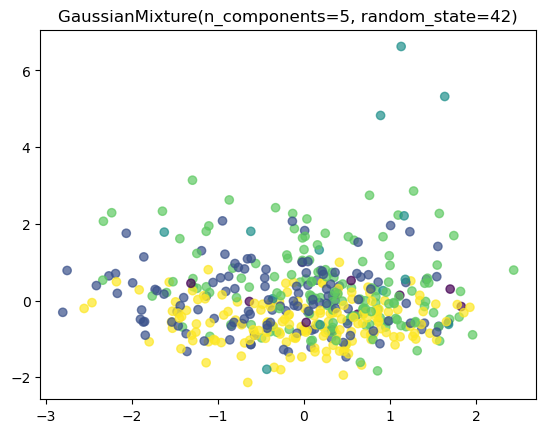

In [35]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=5, random_state=42)

labels_train_gm = gm.fit_predict(X_train_fin)
labels_test_gm = gm.predict(X_test_fin)

purity_train_gm = purity(y_train, labels_train_gm)
purity_test_gm = purity(y_test, labels_test_gm)


print(f"Purity train: {purity_train_gm * 100:.2f}%, Accuracy train: {accuracy_score(y_train, labels_train_gm) * 100:.2f}%")
print(f"Purity test: {purity_test_gm * 100:.2f}%, Accuracy test: {accuracy_score(y_test, labels_test_gm) * 100:.2f}%")

f1, f2 = sel[0], sel[1]
plt.scatter(X_test_fin[f1], X_test_fin[f2], c=labels_test_gm, cmap='viridis', alpha=0.7)
plt.title(f"{gm}")
plt.show()